ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

**Introduction**

Exploratory Data Analysis (EDA) is used to understand the dataset, detect errors, discover patterns, and find relationships between variables before building any model.

![step1.png](attachment:step1.png)

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
#from google.colab import files
#uploaded = files.upload()

In [3]:
#import zipfile
#import io

#zip_file = zipfile.ZipFile(io.BytesIO(uploaded['archive (5).zip']), 'r')
#zip_file.extractall()

In [4]:
# Load Dataset
df = pd.read_csv("Titanic-Dataset.csv",sep=";")
# Display first 5 rows. 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Using head to display the first 5 rows.

Data understanding


In [5]:
# viewing the data types of columns
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

viewing the data types of columns by using df.dtypes

In [6]:
# Statistical summary
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN



The statistical summary shows general information about the dataset. 
The average age of passengers is around 29.7 years, and the average fare is about 32.2. 
The survival rate is about 38%, which means most passengers did not survive. 
Most passengers were in third class. The age ranges from about 0.4 to 80 years, 
and the fare ranges from 0 to about 512, which indicates a large variation in ticket prices.

In [7]:
df.shape

(891, 12)

In [8]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (891, 12) 

number of rows:  891
number of columns:  12


The dataset contains 891 rows and 12 columns. Each row represents a passenger, and each column represents a feature such as age, gender, ticket class, fare, and survival.


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


After exploring the dataset I found missing values in Age, Cabin, and Embarked columns.

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The dataset contains 177 missing values in Age, 687 missing values in Cabin, and 2 missing values in Embarked columns.

In [11]:
df.duplicated().sum()

np.int64(0)

There were no duplicate rows in the dataset.

**Data cleaning**

In [12]:
# Data Cleaning

df = df.drop_duplicates()

df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin safely
if 'Cabin' in df.columns:
    df = df.drop('Cabin', axis=1)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Data Cleaning:

The dataset contained missing values in the Age, Cabin, and Embarked columns. The missing values in the Age column were replaced with the mean value because Age is a numerical feature, and using the mean helps maintain the overall distribution of the data without significantly affecting the results. The missing values in the Embarked column were replaced with the most frequent value (mode) because Embarked is a categorical feature. The Cabin column had a large number of missing values, so it was removed from the dataset as it would not be useful for analysis and could negatively affect the results. Duplicate rows were checked, but no duplicate rows were found in the dataset. Finally, after completing the data cleaning process, the dataset contained no missing values.

**Visualization**

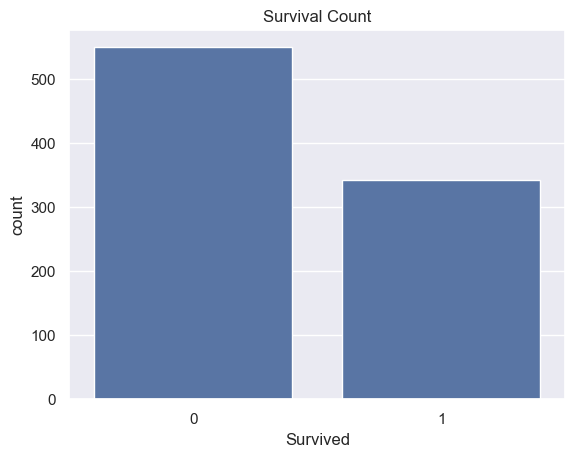

In [13]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

Why this visualization:
This visualization was chosen to show the distribution of survival among passengers.

Insight and pattern:
From the chart, we can see that the number of passengers who did not survive is higher than the number of passengers who survived. This shows that the survival rate was low.

What we learned:
This plot helps us understand the overall survival distribution and gives us a general idea about how many passengers survived compared to those who did not.

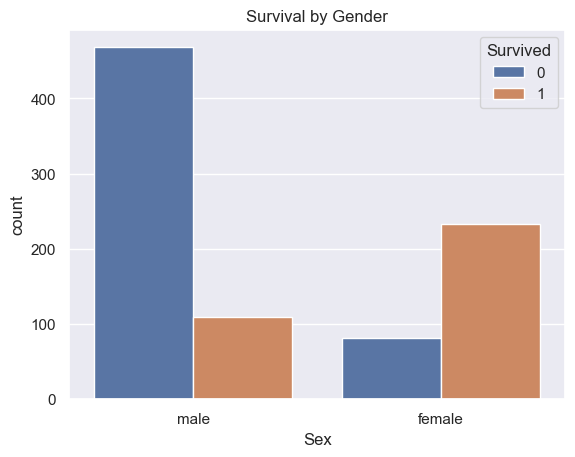

In [14]:
#Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

Why this visualization:
This visualization was chosen to show the relationship between gender and survival.

Insight and important pattern:
The chart clearly shows that females had a much higher survival rate than males. Most females survived, while most males did not survive.

What we learned:
From this visualization, we learn that gender was a very important factor affecting survival on the Titanic. Females had a higher chance of survival compared to males.

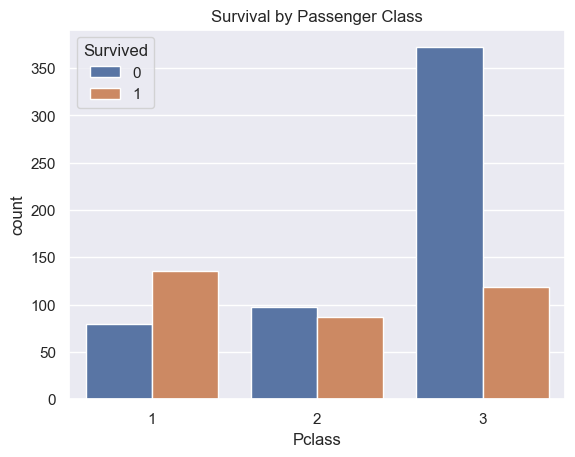

In [15]:
#Survival by Class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

Why this visualization:
This visualization was chosen to show the relationship between passenger class and survival.

Insight and important pattern:
The chart shows that passengers in first class had a higher survival rate compared to passengers in second and third class. Passengers in third class had the lowest survival rate.

What we learned:
From this visualization, we learn that passenger class had a strong impact on survival, and higher-class passengers had a better chance of survival.

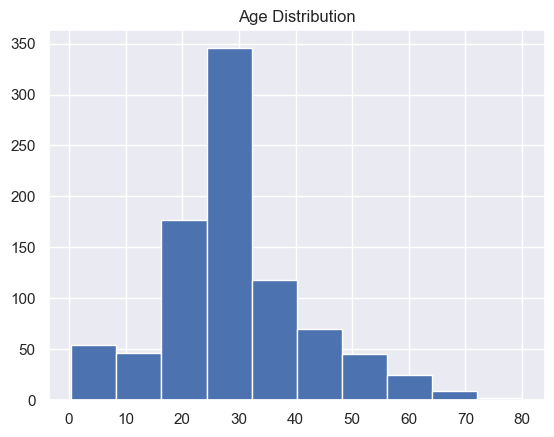

In [16]:
#Age Distribution
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

Why this visualization:
This visualization was chosen to show the distribution of passenger ages. It helps us understand the age range of passengers and identify the most common age groups on the Titanic.

Insight and important pattern:
The histogram shows that most passengers were between 20 and 40 years old. There were fewer children and elderly passengers compared to adults. The age distribution is slightly right-skewed, meaning there are some older passengers but not many.

What we learned:
From this visualization, we learn that the majority of Titanic passengers were young adults. This information can help us further analyze whether age had an effect on survival.

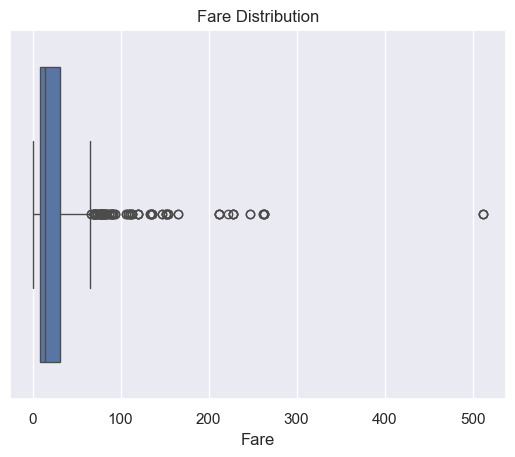

In [17]:
#Fare Boxplot
sns.boxplot(x=df['Fare'])
plt.title("Fare Distribution")
plt.show()

Why this visualization:
This boxplot was chosen to show the distribution of ticket fares and to identify any outliers in the Fare column.

Insight and important pattern:
The boxplot shows that most passengers paid relatively low fares, but there are several outliers where some passengers paid very high fares. This indicates a large variation in ticket prices.

What we learned:
From this visualization, we learn that ticket fares varied significantly among passengers. A small number of passengers paid much higher fares, which likely corresponds to first-class passengers.

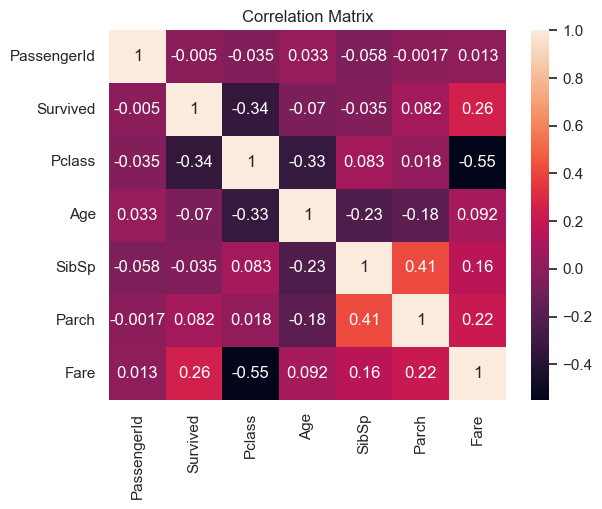

In [18]:
#Correlation Heatmap
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Why this visualization:
This heatmap was used to show the correlation between numerical variables in the dataset. It helps us understand the relationships between different variables.

Insight and important pattern:
The heatmap shows a positive correlation between Fare and Survived, which means that passengers who paid higher fares had a higher chance of survival. There is also a negative correlation between Pclass and Survived, meaning that passengers in lower classes had a lower chance of survival. Age has a weak correlation with survival.

What we learned:
From this heatmap, we learn that passenger class and fare were important factors affecting survival. Fare and class are strongly related to survival, while age has less impact on survival.

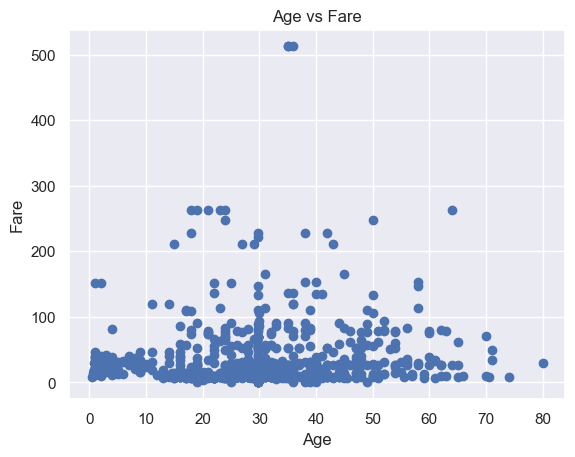

In [19]:
#Age vs Fare
plt.scatter(df['Age'], df['Fare'])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

Why this visualization:
This scatter plot was used to show the relationship between Age and Fare. It helps us see whether ticket fare is related to the passenger's age.

Insight and important pattern:
The scatter plot shows that there is no strong relationship between Age and Fare. Passengers of different ages paid different ticket fares. However, some passengers who paid very high fares were mostly adults.

What we learned:
From this visualization, we learn that fare was not directly related to age. Ticket fare depended more on passenger class rather than age.

Conclusion:

In this project, I explored the Titanic dataset using Exploratory Data Analysis (EDA). I performed data cleaning by handling missing values and removing unnecessary columns, which made the dataset ready for analysis. From the analysis and visualizations, I found that gender, passenger class, and fare had a strong impact on survival.
Females had a higher survival rate than males, and passengers in first class had a higher chance of survival compared to passengers in third class. Passengers who paid higher fares were also more likely to survive. Age had a smaller impact on survival compared to gender and passenger class. Overall, this analysis shows that social class and gender played an important role in survival during the Titanic disaster. This project helped me understand how data cleaning and visualization can be used to discover patterns, relationships, and important insights from data.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
